# **Modelo de predicción de transacciones fraudulentas**

## 0. *Descripción detallada de los atributos dentro del dataset a utilizar*


1. **trans_date_trans_time**: Fecha y hora exacta en que ocurrió la transacción.
- Ejemplo: 2020-12-24 16:56:24

2. **merchant**: Nombre o identificador del comercio donde se realizó la compra.
- Ejemplo: "Fraud_R_7614"

3. **category**: Tipo de comercio o industria.
- Ejemplo: "gas_transport", "shopping_pos", "food_dining".

4. **amt**: Monto de la transacción en dólares.
- Ejemplo: 57.86

5. **city**: Ciudad del cliente que realizó la transacción.

6. **state**: Estado/Región donde vive el cliente.
- Ejemplo: "CA", "TX", "NY".

7. **lat**: Latitud aproximada de la ubicación del cliente.

8. **long**: Longitud aproximada de la ubicación del cliente.

9. **city_pop**: Población (¿en miles?) de la ciudad donde vive el cliente.
Sirve para análisis demográficos o patrones de fraude en ciudades grandes/pequeñas.

10. **job**: Profesión del cliente.
- Ejemplo: "Mechanical engineer", "Nurse".

11. **dob**: Fecha de nacimiento del cliente. Permite calcular su edad en el momento de la transacción.

12. **trans_num**: Número único o código identificador de la transacción. Sirve como primary key.

13. **merch_lat**: Latitud del comercio donde ocurrió la transacción.

14. **merch_long**: Longitud del comercio donde ocurrió la transacción.

15. **is_fraud**: Etiqueta objetivo.
- 0 → transacción legítima
- 1 → transacción fraudulenta

## 1. Importación de Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (recall_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

## 2. Lectura de Archivo

In [4]:
# Leemos el dataset llamado 'fraud_data.csv'
file_name = 'https://raw.githubusercontent.com/darkJCdark/fraud-detection-bank-transactions-ml/refs/heads/main/data/fraud_data.csv'
df = pd.read_csv(file_name)

## 3. Análisis Descriptivo
En esta sección se tendrá el detalle del análisis descriptivo necesario (tipos de datos, conteo de variables, cantidad de nulos, etc)

### 3.1. Descripcion de Variables

In [5]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,04-01-2019 00:58,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,04-01-2019 15:06,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,04-01-2019 22:37,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,04-01-2019 23:06,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,04-01-2019 23:59,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14446 non-null  object 
 1   merchant               14446 non-null  object 
 2   category               14446 non-null  object 
 3   amt                    14446 non-null  float64
 4   city                   14446 non-null  object 
 5   state                  14446 non-null  object 
 6   lat                    14446 non-null  float64
 7   long                   14446 non-null  float64
 8   city_pop               14446 non-null  int64  
 9   job                    14446 non-null  object 
 10  dob                    14446 non-null  object 
 11  trans_num              14446 non-null  object 
 12  merch_lat              14446 non-null  float64
 13  merch_long             14446 non-null  float64
 14  is_fraud               14446 non-null  object 
dtypes:

In [7]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long
count,14446.000000,14446.000000,14446.000000,1.444600e+04,14446.000000,14446.000000
mean,124.430073,39.787692,-110.874225,1.065370e+05,39.787991,-110.874892
std,231.352587,5.317039,12.985813,2.902916e+05,5.360593,12.995596
min,1.000000,20.027100,-165.672300,4.600000e+01,19.032689,-166.670685
25%,12.080000,36.715400,-120.415800,4.930000e+02,36.794655,-120.146253
50%,51.520000,39.666200,-111.098500,1.645000e+03,39.620953,-111.192629
75%,101.030000,41.940400,-101.136000,3.543900e+04,42.275740,-100.446822
max,3261.470000,66.693300,-89.628700,2.383912e+06,67.510267,-88.646366


### 3.2. Conversión de variables a su tipo correcto

In [8]:
df.is_fraud.value_counts() / len(df) * 100

,count
is_fraud,
0,87.221376
1,12.764779
"1""2020-12-24 16:56:24""",0.006922
"0""2019-01-01 00:00:44""",0.006922


In [9]:
# --- Conversión de tipos correctos ---

# Fechas
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], dayfirst=True)
df['dob'] = pd.to_datetime(df['dob'], dayfirst=True)

# Strings
object_cols = [
    'merchant',        # nombre del comercio
    'category',        # categoría
    'city',            # ciudad
    'state',           # estado
    'job',             # profesión
    'trans_num'        # id de la transacción
]

for col in object_cols:
    df[col] = df[col].astype("string")

# Floats (ya vienen bien, pero forzamos por seguridad)
float_cols = ['amt', 'lat', 'long', 'merch_lat', 'merch_long']
for col in float_cols:
    df[col] = df[col].astype(float)

# Enteros (ya correcto)
df['city_pop'] = df['city_pop'].astype(int)

# Variable objetivo (0/1)
index_error_0 = df[df['is_fraud'] == '1"2020-12-24 16:56:24"'].index
index_error_1 = df[df['is_fraud'] == '0"2019-01-01 00:00:44"'].index

df.loc[index_error_0, 'is_fraud'] = 1
df.loc[index_error_1, 'is_fraud'] = 0

df['is_fraud'] = df['is_fraud'].astype(int)

print(df.dtypes)


trans_date_trans_time    datetime64[ns]
merchant                 string[python]
category                 string[python]
amt                             float64
city                     string[python]
state                    string[python]
lat                             float64
long                            float64
city_pop                          int64
job                      string[python]
dob                      datetime64[ns]
trans_num                string[python]
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object


### 3.3. Conversión de Fechas

In [10]:
# conversion de la edad y fecha
df[['trans_date_trans_time','dob']].nunique()

# como se puede observar, son variables categóricas, pero tienen demasiados tipos
# por lo que se optará por hacer transformaciones

,0
trans_date_trans_time,12126
dob,187


In [11]:
# Para el caso de dob - se transformará en una variable numérica con la edad exacta del cliente
df['edad'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
df['edad']

,edad
0,79
1,79
2,79
3,79
4,79
...,...
14441,42
14442,62
14443,45
14444,79


In [12]:
# se elimina dob, porque ya no se usara, se utilizará "edad" en años
df = df.drop(columns='dob')

In [13]:
# Para la fecha de la transacción, se considerará solo el mes en el que sucedió, ya que el año y el día generarían overfitting
# debido a que no son repetibles en el tiempo
df['trans_date_trans_time'] = df['trans_date_trans_time'].dt.strftime('%B')
df['trans_date_trans_time'] = df['trans_date_trans_time'].astype("string")
df['trans_date_trans_time']

,trans_date_trans_time
0,January
1,January
2,January
3,January
4,January
...,...
14441,January
14442,January
14443,January
14444,January


### 3.4. Conteo de Variable Objetivo

In [14]:
df.is_fraud.value_counts() / len(df) * 100

,count
is_fraud,
0,87.228298
1,12.771702


### 3.5. Número de Únicos

In [15]:
df.nunique()

,0
trans_date_trans_time,12
merchant,693
category,14
amt,9266
city,176
state,13
lat,183
long,183
city_pop,174
job,163


## 4. Tratamiento de variables numéricas

### 4.1. Correlaciones

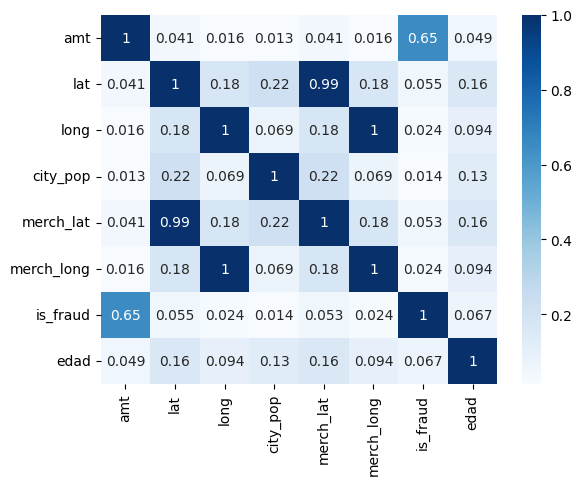

In [16]:
df_num = df.select_dtypes('number').copy(deep=True)
correlations = df_num.corr()
sns.heatmap(abs(correlations), cmap="Blues", annot=True)
plt.show()

Debido a que merc_lat y lat presentan mucha correlación (0.99), al igual que merch_long y long (1), podemos considerar eliminarlas. Esta correlación se puede explicar debido a que las transacciones analizadas son realizadas en un mismo lugar o en coordenadas suficientemente cercanas, por lo que la diferencia entre latitud y longitud del cliente y el mercader es practicamente cero.

In [17]:
# Eliminamos las columnas merch_lat y merch_long
df = df.drop('merch_lat', axis=1)
df = df.drop('merch_long', axis=1)

### 4.2. Outliers

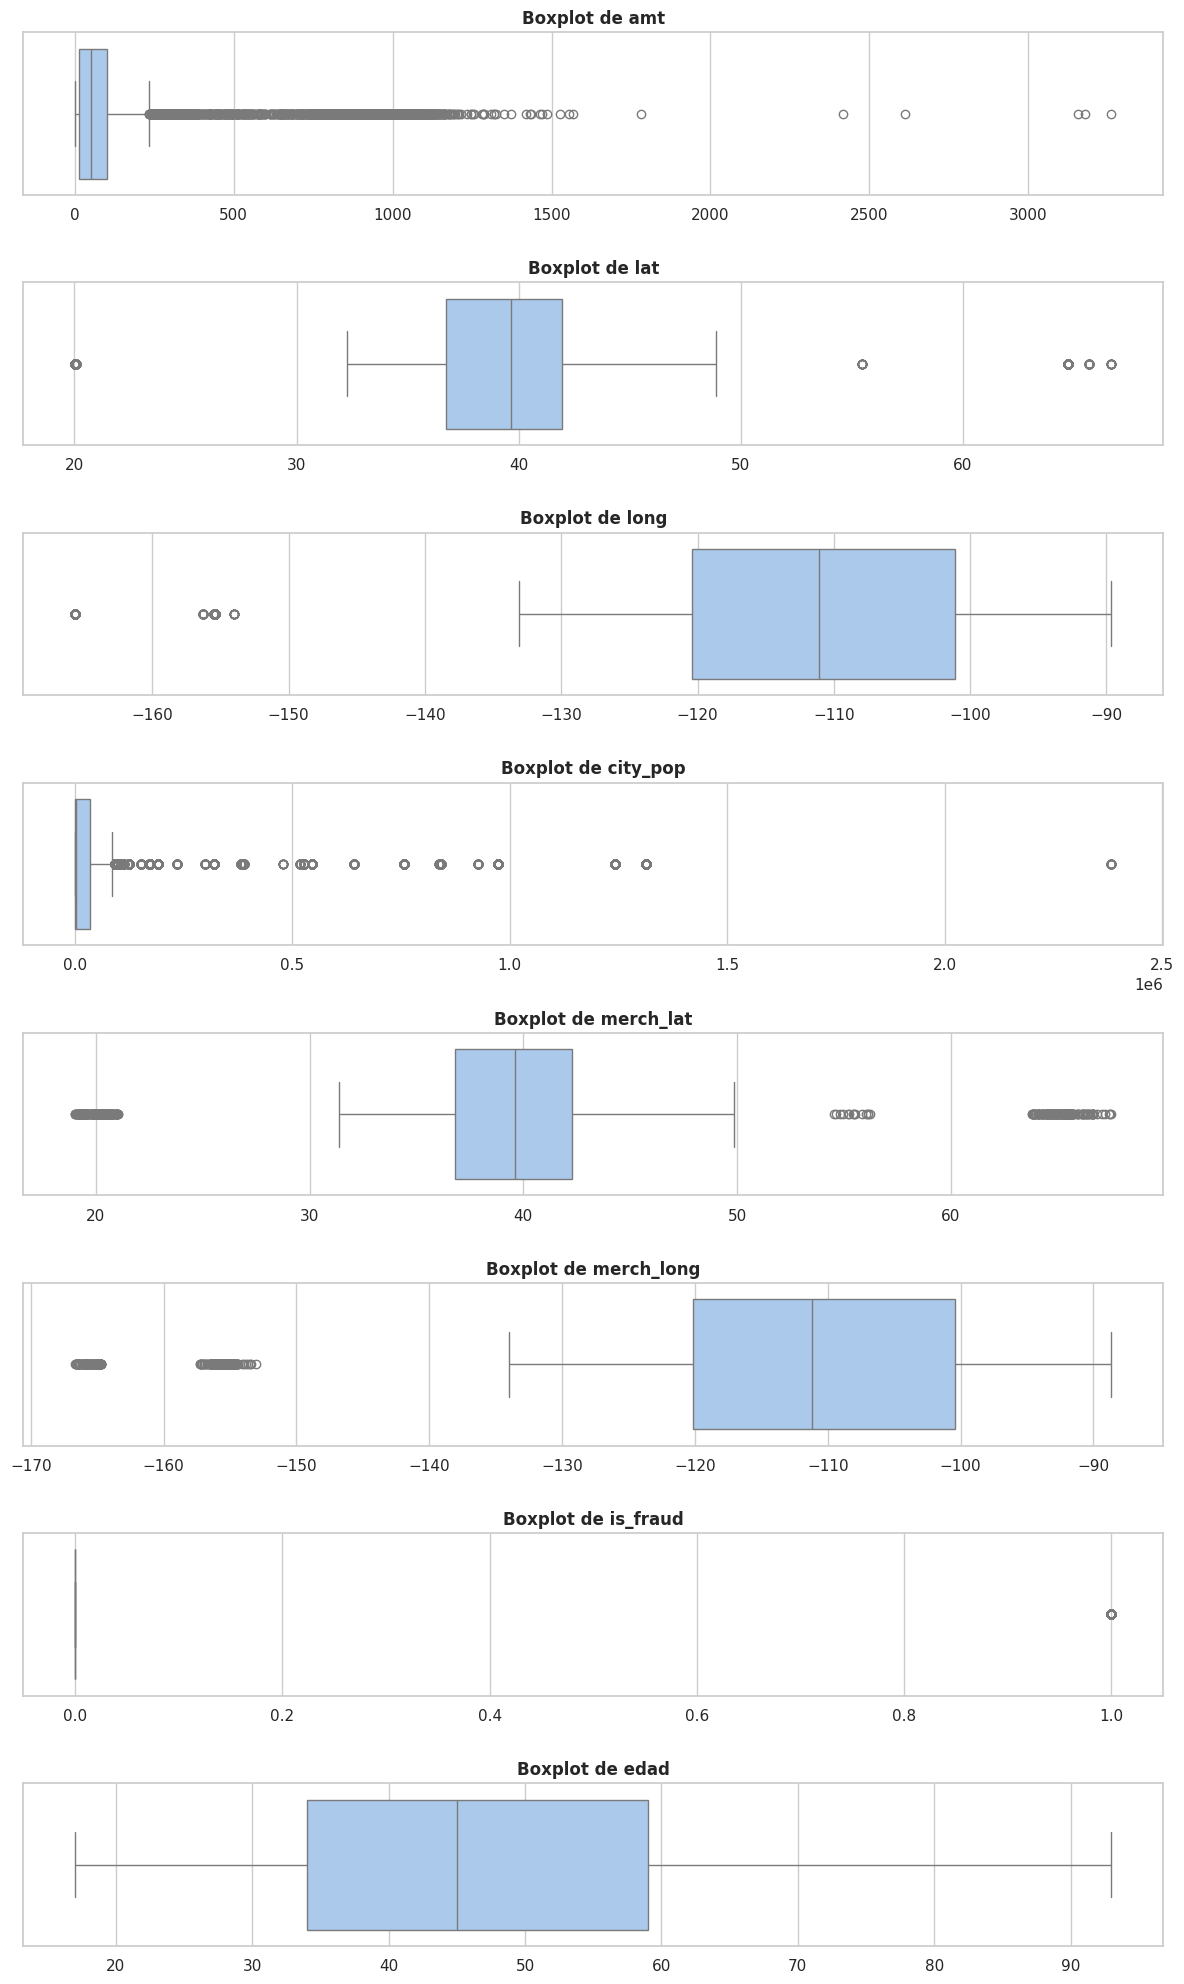

In [18]:
# Presentamos un gráfico que nos permite visualizarlos de mejor forma
sns.set(style="whitegrid", palette="pastel")

# Cantidad de columnas numéricas
num_cols = df_num.columns.tolist()
n = len(num_cols)

# Tamaño dinámico de la figura
plt.figure(figsize=(12, 2.5 * n))

# Generar un subplot por cada variable numérica
for i, col in enumerate(num_cols, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(x=df_num[col], orient="h")
    plt.title(f"Boxplot de {col}", fontsize=12, fontweight="bold")
    plt.xlabel("")  # limpio
    plt.tight_layout()

plt.show()

Se toma la decisión de NO eliminar outliers, pues estos datos atípicos son los que pueden ser más representativos para detectar un fraude.

## 5. Escalamiento de Variables

In [19]:
# Paso 0: elegir columnas a escalar
df_num = df.select_dtypes('number').copy(deep=True) # Actualizamos luego de eliminar columnas numéricas
columnas = df_num.columns # Sujeto a cambios por si se quiere escalar columnas específicas
# Paso 1: se guarda el scaler en una variable
scaler = MinMaxScaler()
# Paso 2: se aplica el método fit del scaler sobre el conjunto de datos (con las columnas donde se va aplicar)
scaler.fit(df[columnas])
# Paso 3: se aplica el método transform del scaler sobre el conjunto de datos y se guarda el resultado.
df[columnas] = scaler.transform(df[columnas])

## 6. Tratamiento de variables categóricas
Las variables que no son numéricas son las siguientes:
<br>

| Variable              | Tipo de Dato    |
|-----------------------|-----------------|
| merchant              | string[python]  |
| category              | string[python]  |
| city                  | string[python]  |
| state                 | string[python]  |
| job                   | string[python]  |
| trans_num             | string[python]  |

<br>

### 6.1. Tratamiento de Strings

In [20]:
# Obtenemos las variables de tipo string
df_str = df.select_dtypes("string[python]").copy(deep=True)
df_str.head()

,trans_date_trans_time,merchant,category,city,state,job,trans_num
0,January,"""Stokes, Christiansen and Sipes""",grocery_net,Wales,AK,"""Administrator, education""",a3806e984cec6ac0096d8184c64ad3a1
1,January,Predovic Inc,shopping_net,Wales,AK,"""Administrator, education""",a59185fe1b9ccf21323f581d7477573f
2,January,Wisozk and Sons,misc_pos,Wales,AK,"""Administrator, education""",86ba3a888b42cd3925881fa34177b4e0
3,January,Murray-Smitham,grocery_pos,Wales,AK,"""Administrator, education""",3a068fe1d856f0ecedbed33e4b5f4496
4,January,Friesen Lt,health_fitness,Wales,AK,"""Administrator, education""",891cdd1191028759dc20dc224347a0ff


In [21]:
df_str.nunique()

,0
trans_date_trans_time,12
merchant,693
category,14
city,176
state,13
job,163
trans_num,14383


**Notamos que**: El parámetro trans_num no aporta valor predictivo porque es únicamente un identificador único de cada registro o transacción. No tiene relación directa con las características del fraude, así que no influye en el análisis o el modelo.

In [22]:
# Eliminamos trans_num
df = df.drop('trans_num', axis=1)

In [23]:
for c in df_str.columns:
    print(f"Columna: {c}")
    print(df_str[c].unique())
    print("-" * 100)

Columna: trans_date_trans_time
<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: string
----------------------------------------------------------------------------------------------------
Columna: merchant
<StringArray>
[ '"Stokes, Christiansen and Sipes"',                      'Predovic Inc',
                   'Wisozk and Sons',                    'Murray-Smitham',
                        'Friesen Lt',     '"Raynor, Reinger and Hagenes"',
                    'Heller-Langosh',                     'Padberg-Welch',
                 'McGlynn-Heathcote',                   'Dooley-Thompson',
 ...
                   'Schroeder Group',   '"Douglas, DuBuque and McKenzie"',
                    'Lemke and Sons',                     'Smitham-Boehm',
 '"Ritchie, Oberbrunner and Cremin"', '"McLaughlin, Armstrong and Koepp"',
       '"Reichel, Bradtke and Bla

In [24]:
# Codificamos con label-encoding debido a la cantidad elevada de valores únicos
df_str = df.select_dtypes("string[python]").copy(deep=True) # Actualizamos luego de eliminar columnas tipo string
le = LabelEncoder()
for col in df_str.columns:
    df[col] = le.fit_transform(df[col])

# 7. Evaluación de Modelos

## 7.1. Separar data en train y validacion

In [25]:
# separar el dataset en atributos (X)  y  target (y)
array = df.values
X = df.drop(columns=["is_fraud"])  # atributos
y = df["is_fraud"]                 # target

# realizar el train-test split
test_size = 0.30    # proporcion de muestras para validacion: 30%
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print('Training: %d ejemplos. Test: %d ejemplos' % (len(y_train), len(y_test)))

Training: 10112 ejemplos. Test: 4334 ejemplos


## 7.2. Selección de Pipelines de Clasificación

In [26]:
# Creación de pipes
pipeline_lr  = Pipeline([('lr', LogisticRegression())])
pipeline_rfc = Pipeline([('rfc', RandomForestClassifier())])

pipes_dict = [('Logistic Regression', pipeline_lr), ('Random Forest', pipeline_rfc)]

In [27]:
# Obtención de Scores
for i, (name, p) in enumerate(pipes_dict, 1):
  scores = cross_val_score(p, X, y, cv=5, scoring='recall')
  print(f"{i}. {name} - Score: {scores.mean()} +/- {scores.std()}")

1. Logistic Regression - Score: 0.44498644986449865 +/- 0.11994617908161484
2. Random Forest - Score: 0.9089430894308942 +/- 0.09346411618341409


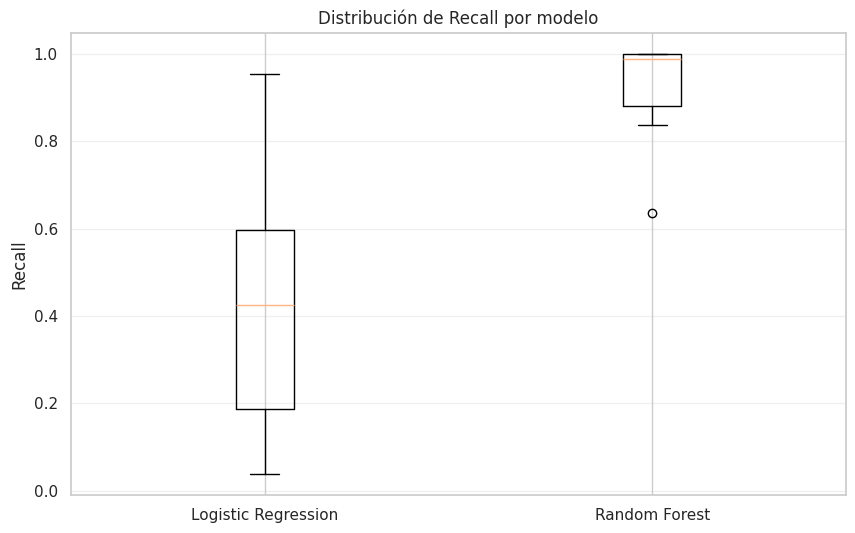

In [28]:
# boxplot de la distribución de la métrica
all_scores = []
all_labels = []
for name, p in pipes_dict:
    scores = cross_val_score(p, X, y, cv=12, scoring='recall')
    all_scores.append(scores)
    all_labels.append(name)

plt.figure(figsize=(10, 6))
plt.boxplot(all_scores, labels=all_labels)
plt.ylabel('Recall')
plt.title('Distribución de Recall por modelo')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 8. Optimización de hiperparámetros
A partir del analisis del recall, decidimos optimizar los hiperparámetros de RF (Random Forest).

Tenemos la siguiente documentación:

https://qu4nt.github.io/sklearn-doc-es/modules/generated/sklearn.ensemble.RandomForestClassifier.html

A partir de esta, identificamos algunos hiperparámetros de interés:

| Hiperparámetro   | Descripción | Importancia |
| ---------------- | ----------- | ----------- |
| n_estimators     | Número de árboles en el bosque. | Más árboles implica mayor estabilidad y precisión, pero más coste computacional. |
| max_depth        | Profundidad máxima permitida para cada árbol. | Controla el sobreajuste. Árboles profundos capturan más detalle |
| max_features     | Número de características seleccionadas en cada división. | Influye en la diversidad entre árboles, evitando sobreajuste. |


In [29]:
# Creamos el diccionario de hiperparámetros
param_grid = {
    'rfc__n_estimators': [10, 100, 200, 500],
    'rfc__max_depth': [None, 10, 20, 30],
    'rfc__max_features': [None, 'sqrt', 'log2'],
}

OJO: La siguiente optimización puede tardar un tiempo considerable. Esto se debe a que el GridSearchCV está haciendo un búsqueda exhaustiva combinando:
- 4 opciones de n_estimators
- 4 opciones de max_depth
- 3 opciones de max_features

Total de combinaciones: 4 × 4 × 3 = 48 modelos

Y eso multiplicado por cv=3 (3 folds de validación cruzada):

48 × 3 = 144 entrenamientos del Random Forest

El valor de n_jobs=-1 permite que se ejecute en todos los núcleos que brinda el procesador del Colab, lo cuál supone una mejora en la eficiencia de ejecución.

In [30]:
# Aplicamos la optimización (puede tomar 15-20min)
grid = GridSearchCV(pipeline_rfc, param_grid, cv=3, scoring='recall', n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('rfc', RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'rfc__max_depth': [None, 10, 20, 30],
                         'rfc__max_features': [None, 'sqrt', 'log2'],
                         'rfc__n_estimators': [10, 100, 200, 500]},
             scoring='recall')

In [31]:
# Revisamos los mejores parámetros
grid.best_params_

{'rfc__max_depth': 30, 'rfc__max_features': None, 'rfc__n_estimators': 100}

In [32]:
# Ajustamos el modelo final
rf_final = RandomForestClassifier(
    max_depth=20,
    max_features=None,
    n_estimators=100,
    random_state=42
)

# 9. Entrenamiento del modelo final

In [33]:
rf_final.fit(X_train, y_train)
y_predicted = rf_final.predict(X_test)
print(f"Score en test: {recall_score(y_test, y_predicted)}")

Score en test: 0.9530075187969925


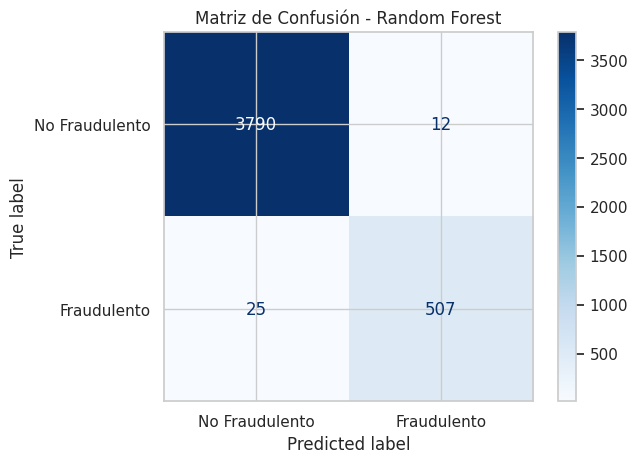

In [34]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Fraudulento", "Fraudulento"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Random Forest")
plt.show()